# Ejercicio 8 - Incorporacion de datos de 2025 y analisis completo

## 0. Configuracion

In [1]:
import os
import subprocess
import sys
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(RAIZ)
sys.path.insert(0, str(RAIZ / "scripts"))

import indicadores
from run_sql import cargar_consultas

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
TIPOS = ["yellow", "green"]
COLORES_ANIO = {2024: "#9AA5B1", 2025: "#4C72B0", 2026: "#DD8452"}

CONSULTAS = cargar_consultas(Path("sql/07_indicadores.sql"))
con = None   # conexion de solo lectura a data/processed/indicadores.duckdb (se abre despues de construirla)


def q(sql):
    # Ejecuta la consulta en DuckDB y devuelve el resultado como DataFrame.
    inicio = time.perf_counter()
    df = con.sql(sql).df()
    print(f"{len(df)} filas | {time.perf_counter() - inicio:.2f} s")
    return df


def indicador(nombre, mostrar_sql=True):
    # Muestra la consulta del indicador (sql/07_indicadores.sql) y devuelve su tabla.
    descripcion, sql = CONSULTAS[nombre]
    if mostrar_sql:
        print(descripcion, "\n")
        print(sql, "\n")
    return q(f"SELECT * FROM {nombre}")


def por_anio(df, x, y, titulo, etiqueta_y):
    # Un grafico por tipo de taxi con una linea por anio.
    fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
    for eje, tipo in zip(ejes, TIPOS):
        for anio, d in df[df.tipo == tipo].groupby("anio"):
            eje.plot(d[x], d[y], marker="o", ms=3, color=COLORES_ANIO.get(anio), label=str(anio))
        eje.set_title(f"{tipo}: {titulo}")
        eje.set_xlabel(x)
        eje.set_ylabel(etiqueta_y)
        eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}" if abs(v) >= 100 else f"{v:,.1f}")
    ejes[0].legend()
    plt.tight_layout()
    plt.show()


def en_el_tiempo(df, columnas, titulo):
    # Un grafico por tipo de taxi con la evolucion mensual de varias columnas.
    fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
    for eje, tipo in zip(ejes, TIPOS):
        d = df[df.tipo == tipo]
        for columna in columnas:
            eje.plot(d.fecha, d[columna], marker="o", ms=3, label=columna)
        eje.set_title(f"{tipo}: {titulo}")
        eje.tick_params(axis="x", rotation=45)
    ejes[0].legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def promedio_anual(df, columnas):
    # Promedio de los valores mensuales de cada anio.
    return df.groupby(["tipo", "anio"], sort=False)[columnas].mean().round(2)


print("DuckDB", duckdb.__version__)

DuckDB 1.5.5


## 8.1 Cambio en el sistema de descarga

In [2]:
import download_data

print("Anios por defecto del script:", download_data.ANIOS_POR_DEFECTO)

Anios por defecto del script: (2024, 2025, 2026)


## 8.2 Nueva ejecucion de la descarga

In [3]:
inicio = time.perf_counter()
proceso = subprocess.run([sys.executable, "scripts/download_data.py"], capture_output=True, text=True)
salida = proceso.stdout.splitlines()
print(f"Codigo de salida: {proceso.returncode} | {time.perf_counter() - inicio:.1f} s\n")

conteo = pd.Series({
    "descargados en esta ejecucion": sum("listo (" in l for l in salida),
    "ya existian y se omitieron": sum("se omite" in l for l in salida),
    "aun no publicados": sum("aun no publicado" in l for l in salida),
})
display(conteo.to_frame("meses"))
print("\n".join(salida[salida.index("RESUMEN") - 1:]))

Codigo de salida: 0 | 15.5 s



,meses
descargados en esta ejecucion,0
ya existian y se omitieron,64
aun no publicados,8


RESUMEN
  anios         : 2024, 2025, 2026
  descargados   : 0
  ya existian   : 64
  no publicados : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  fallidos      : 0
  manifiesto    : data/raw/manifest.csv


In [4]:
con = duckdb.connect()   # conexion temporal en memoria para revisar los archivos
q('''
SELECT anio, tipo, estado, count(*) AS meses,
       round(sum(bytes_local) / 1024 / 1024, 1) AS mib_locales,
       bool_and(bytes_local = bytes_servidor) FILTER (estado <> 'no_publicado') AS tamanios_coinciden
FROM read_csv('data/raw/manifest.csv')
GROUP BY ALL
ORDER BY anio, tipo DESC, estado
''')

8 filas | 0.08 s


,anio,tipo,estado,meses,mib_locales,tamanios_coinciden
0,2024,yellow,completo,12,660.90,True
1,2024,green,completo,12,15.20,True
2,2025,yellow,completo,12,791.50,True
3,2025,green,completo,12,13.80,True
4,2026,yellow,completo,8,487.80,True
5,2026,yellow,no_publicado,4,NaN,<NA>
6,2026,green,completo,8,7.90,True
7,2026,green,no_publicado,4,NaN,<NA>


## 8.3 Las consultas anteriores sobre el conjunto ampliado

### Consultas del Ejercicio 3 sin cambios

In [5]:
CONSULTAS_EJ3 = cargar_consultas(Path("sql/03_exploracion_parquet.sql"))
for nombre in ["q01_cantidad_archivos", "q03_total_registros", "q12_fechas_fuera_de_periodo"]:
    descripcion, sql = CONSULTAS_EJ3[nombre]
    print(f"\n{nombre}: {descripcion}")
    display(q(sql))


q01_cantidad_archivos: 3.1 Cantidad de archivos Parquet disponibles, por tipo de taxi y anio.


6 filas | 0.22 s


,tipo,anio,archivos,primer_mes,ultimo_mes
0,green,2024,12,2024-01,2024-12
1,green,2025,12,2025-01,2025-12
2,green,2026,8,2026-01,2026-08
3,yellow,2024,12,2024-01,2024-12
4,yellow,2025,12,2025-01,2025-12
5,yellow,2026,8,2026-01,2026-08



q03_total_registros: 3.2 Total de registros por tipo leyendo los datos (valida el resultado de q02).


3 filas | 1.93 s


,tipo,registros
0,green,1588707
1,yellow,119595677
2,TOTAL,121184384



q12_fechas_fuera_de_periodo: 3.6 Viajes cuya fecha de inicio no corresponde al mes del archivo.


2 filas | 2.69 s


,tipo,registros,fuera_del_mes,mas_de_un_mes_antes,despues_del_mes,pickup_minimo,pickup_maximo
0,yellow,119595677,780,73,209,2001-01-01 09:23:58,2026-08-31 23:59:59
1,green,1588707,510,18,228,2008-12-31 00:00:00,2026-08-31 23:58:28


### Vistas del Ejercicio 4 (las mismas de `sql/07_indicadores.sql`) sin cambios

In [6]:
for nombre in ["viajes", "viajes_limpios"]:
    con.sql(f"CREATE OR REPLACE VIEW {nombre} AS {CONSULTAS[nombre][1]}")

q('''
SELECT anio, tipo,
       v.registros,
       l.registros                                   AS registros_limpios,
       round(100.0 * l.registros / v.registros, 2)  AS pct_conservado
FROM (SELECT anio, tipo, count(*) AS registros FROM viajes GROUP BY ALL) v
JOIN (SELECT anio, tipo, count(*) AS registros FROM viajes_limpios GROUP BY ALL) l
  USING (anio, tipo)
ORDER BY anio, tipo DESC
''')

6 filas | 7.44 s


,anio,tipo,registros,registros_limpios,pct_conservado
0,2024,yellow,41169720,39562556,96.10
1,2024,green,660218,614284,93.04
2,2025,yellow,48722602,44021895,90.35
3,2025,green,591375,553720,93.63
4,2026,yellow,29703355,28145839,94.76
5,2026,green,337114,319435,94.76


### Por que los amarillos de 2025 pierden mas registros en la limpieza

In [7]:
q('''
SELECT tipo, anio,
       round(100.0 * avg((NOT duracion_min BETWEEN 1 AND 180)::INT), 2)                        AS pct_duracion_fuera_de_rango,
       round(100.0 * avg((trip_distance <= 0 OR trip_distance > 100)::INT), 2)                 AS pct_distancia_fuera_de_rango,
       round(100.0 * avg((fare_amount < 0 OR total_amount < 0 OR tip_amount < 0)::INT), 2)    AS pct_montos_negativos
FROM viajes
GROUP BY ALL
ORDER BY tipo DESC, anio
''')

6 filas | 6.37 s


,tipo,anio,pct_duracion_fuera_de_rango,pct_distancia_fuera_de_rango,pct_montos_negativos
0,yellow,2024,1.28,1.89,1.78
1,yellow,2025,2.28,2.89,5.86
2,yellow,2026,2.33,3.21,0.55
3,green,2024,3.58,5.27,0.33
4,green,2025,4.14,4.17,0.30
5,green,2026,3.73,3.64,0.30


In [8]:
con.close()

## 8.4 Indicadores y tablero con los tres anios

No hubo que cambiar ninguna consulta de los indicadores: leen `data/raw/*/*/*.parquet` y separan por anio, asi que 2025 entra solo al reconstruir la base y el tablero.

In [9]:
inicio = time.perf_counter()
resumen = pd.DataFrame(indicadores.construir(), columns=["tabla", "filas", "segundos"])
print(f"Base construida en {time.perf_counter() - inicio:.1f} s")
display(resumen)

proceso = subprocess.run([sys.executable, "scripts/tablero_metabase.py"], capture_output=True, text=True)
print(proceso.stdout or proceso.stderr)

con = duckdb.connect(str(indicadores.BASE), read_only=True)
q("SELECT tipo, anio, count(*) AS meses, min(fecha) AS desde, max(fecha) AS hasta FROM i01_demanda_mensual GROUP BY ALL ORDER BY tipo DESC, anio")

Base construida en 77.3 s


,tabla,filas,segundos
0,zonas,265,0.46
1,i01_demanda_mensual,64,6.44
2,i02_resumen_anual,6,12.66
3,i03_demanda_por_hora,144,5.64
4,i04_velocidad_por_hora,144,6.86
5,i05_viaje_tipico,64,9.18
6,i06_costo_y_recargos,64,8.06
7,i07_formas_pago,64,5.93
8,i08_propinas,64,6.31
9,i09_origen_borough,46,7.07


  I1 Viajes por dia en cada mes                   32 filas
  I2 Resumen por anio                              3 filas
  I3 Porcentaje de viajes por hora                72 filas
  I4 Velocidad mediana por hora                   72 filas
  I5 Viaje tipico (medianas)                      32 filas
  I6 Costo del viaje y peso de los recargos       32 filas
  I7 Formas de pago (% de viajes)                 32 filas
  I8 Propinas con tarjeta                         32 filas
  I9 Origen de los viajes por borough             15 filas
  I10 Registros descartados por la limpieza       32 filas
Tablero listo: http://localhost:3001/dashboard/6 (usuario admin@lab8.local)

6 filas | 0.03 s


,tipo,anio,meses,desde,hasta
0,yellow,2024,12,2024-01-01,2024-12-01
1,yellow,2025,12,2025-01-01,2025-12-01
2,yellow,2026,8,2026-01-01,2026-08-01
3,green,2024,12,2024-01-01,2024-12-01
4,green,2025,12,2025-01-01,2025-12-01
5,green,2026,8,2026-01-01,2026-08-01


## 8.5 Evolucion de los indicadores

### Resumen por anio

In [10]:
i02 = indicador("i02_resumen_anual", mostrar_sql=False)
i05 = indicador("i05_viaje_tipico", mostrar_sql=False)
i06 = indicador("i06_costo_y_recargos", mostrar_sql=False)
i07 = indicador("i07_formas_pago", mostrar_sql=False)
i08 = indicador("i08_propinas", mostrar_sql=False)
i10 = indicador("i10_calidad_datos", mostrar_sql=False)

evolucion = (i02.set_index(["tipo", "anio"])[["meses", "viajes_por_dia", "ingreso_por_dia_usd", "pct_aeropuerto"]]
             .join(promedio_anual(i05, ["distancia_mediana_mi", "duracion_mediana_min"]))
             .join(promedio_anual(i06, ["total_mediano_usd", "recargos_promedio_usd", "pct_con_cargo_cbd"]))
             .join(promedio_anual(i07, ["pct_tarjeta", "pct_efectivo", "pct_flex_fare"]))
             .join(promedio_anual(i08, ["propina_mediana_pct"]))
             .join(promedio_anual(i10, ["pct_descartado"])))
evolucion.T

6 filas | 0.00 s
64 filas | 0.00 s
64 filas | 0.00 s
64 filas | 0.00 s
64 filas | 0.00 s
64 filas | 0.01 s


tipo                        yellow                               green                    
anio                          2024         2025         2026      2024      2025      2026
meses                        12.00        12.00         8.00     12.00     12.00      8.00
viajes_por_dia          108,094.00   120,608.00   115,826.00  1,678.00  1,517.00  1,315.00
ingreso_por_dia_usd   3,091,076.00 3,476,222.00 3,494,819.00 40,392.00 38,091.00 33,293.00
pct_aeropuerto               10.53         9.15         8.39      4.26      3.77      3.39
distancia_mediana_mi          1.79         1.89         1.94      1.99      2.09      2.16
duracion_mediana_min         13.12        13.58        14.16     12.08     12.82     13.44
total_mediano_usd            21.18        22.07        23.61     19.33     20.14     20.58
recargos_promedio_usd         4.87         5.24         5.52      3.21      4.31      5.77
pct_con_cargo_cbd             0.00        73.08        72.66      0.00      9.68      8.55
pct_tarjeta                  76.21        68.82        65.24     68.93     69.22     65.59
pct_efectivo                 13.30         9.72         9.00     26.92     22.15     19.30
pct_flex_fare                 9.16        19.94        25.16      3.81      8.35     14.91
propina_mediana_pct          25.78        26.44        26.45     23.44     23.48     23.61
pct_descartado                3.90         9.59         5.27      6.96      6.32      5.25

### Mismos meses en los tres anios (enero a agosto)

2026 solo tiene publicados enero a agosto, y esos meses son de los mas bajos del anio. Para comparar sin ese sesgo se usan solo esos meses en los tres anios.

In [11]:
i01 = indicador("i01_demanda_mensual", mostrar_sql=False)
meses_2026 = i01[i01.anio == i01.anio.max()].mes.unique()
mismos = i01[i01.mes.isin(meses_2026)]
comparable = mismos.groupby(["tipo", "anio"], sort=False).agg(viajes=("viajes", "sum"), dias=("dias", "sum"))
comparable["viajes_por_dia"] = (comparable.viajes / comparable.dias).round()
comparable["cambio_vs_anio_anterior_pct"] = (100 * comparable.groupby(level="tipo").viajes_por_dia.pct_change()).round(1)
comparable

64 filas | 0.00 s


viajes  dias  viajes_por_dia  cambio_vs_anio_anterior_pct
tipo   anio                                                             
yellow 2024  25419708   244      104,179.00                          NaN
       2025  28599585   243      117,694.00                        13.00
       2026  28145839   243      115,826.00                        -1.60
green  2024    412460   244        1,690.00                          NaN
       2025    369682   243        1,521.00                       -10.00
       2026    319435   243        1,315.00                       -13.50

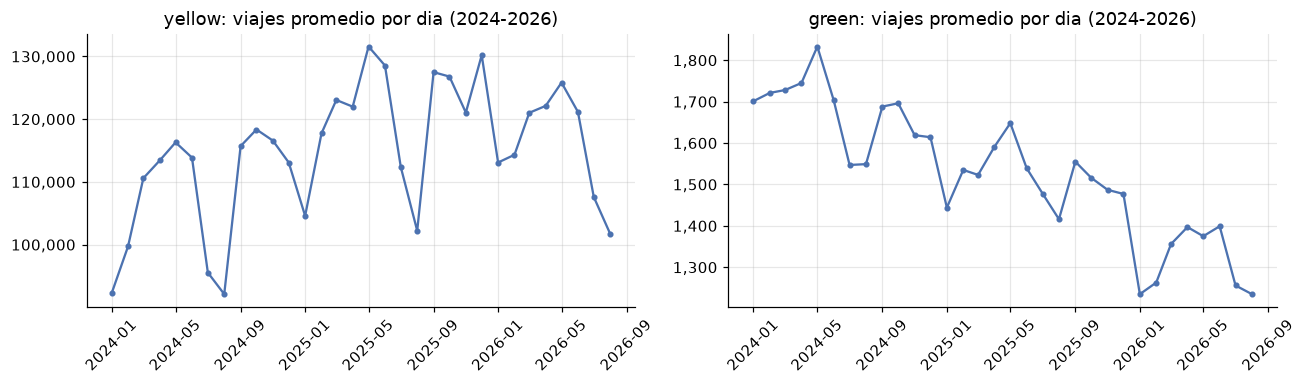

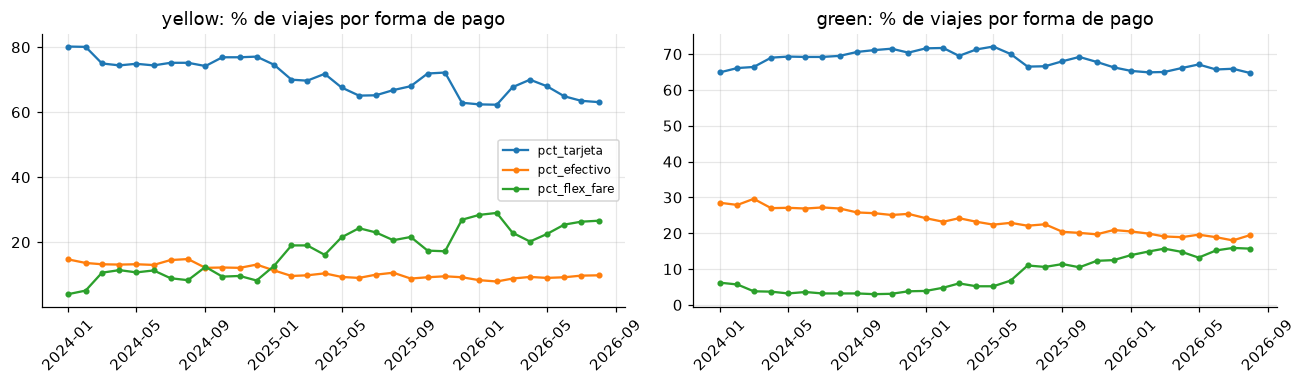

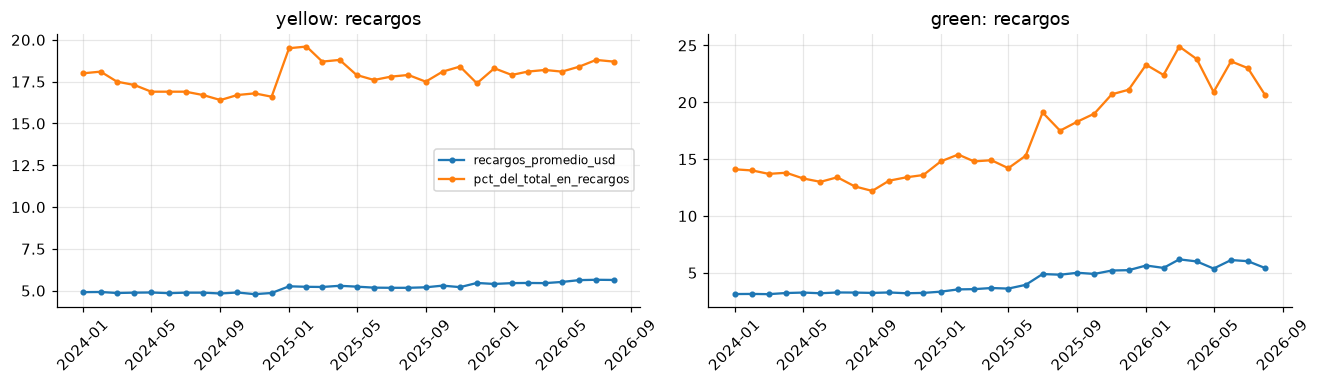

In [12]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 3.6))
for eje, tipo in zip(ejes, TIPOS):
    d = i01[i01.tipo == tipo]
    eje.plot(d.fecha, d.viajes_por_dia, marker="o", ms=3, color="#4C72B0")
    eje.set_title(f"{tipo}: viajes promedio por dia (2024-2026)")
    eje.yaxis.set_major_formatter(lambda v, _: f"{v:,.0f}")
    eje.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

en_el_tiempo(i07, ["pct_tarjeta", "pct_efectivo", "pct_flex_fare"], "% de viajes por forma de pago")
en_el_tiempo(i06, ["recargos_promedio_usd", "pct_del_total_en_recargos"], "recargos")

### El cargo por congestion del sur de Manhattan (CBD)

In [13]:
d = i06[(i06.fecha >= "2024-10-01") & (i06.fecha <= "2025-04-01")]
d.pivot(index="fecha", columns="tipo", values=["pct_con_cargo_cbd", "recargos_promedio_usd", "total_mediano_usd"])

pct_con_cargo_cbd        recargos_promedio_usd        total_mediano_usd       
tipo                   green yellow                 green yellow             green yellow
fecha                                                                                    
2024-10-01              0.00   0.00                  3.27   4.89             19.83  21.84
2024-11-01              0.00   0.00                  3.20   4.79             19.32  21.36
2024-12-01              0.00   0.00                  3.23   4.86             19.20  21.85
2025-01-01              7.30  65.90                  3.34   5.26             18.60  20.35
2025-02-01              8.90  74.10                  3.54   5.23             18.84  20.70
2025-03-01             10.10  74.40                  3.56   5.22             19.45  21.42
2025-04-01             10.50  74.10                  3.66   5.29             19.85  21.60

## Respuestas

8.1 ¿Que se modifico en el sistema de descarga?

Igual que en el Ejercicio 5, solo hubo que agregar 2025 a los anios por defecto del script, que ahora son 2024, 2025 y 2026. Tambien se actualizo la descripcion del script. La logica de descarga no cambio. En la primera corrida se bajaron los 24 archivos de 2025, 12 amarillos (791.5 MiB) y 12 verdes (13.8 MiB).

8.2 ¿Se evito descargar otra vez lo que ya existia?

Si. En la primera corrida con 2025, los 40 archivos de 2024 y 2026 aparecieron como ya existentes y completos. En la corrida de la seccion 8.2 no se descargo nada: los 64 archivos se omitieron y los 8 meses de septiembre a diciembre de 2026 siguen sin publicarse. El manifiesto confirma que todos los archivos tienen el mismo tamanio que en el servidor.

8.3 ¿Siguen funcionando las consultas anteriores?

Si, todas funcionan sin cambios. Las consultas del Ejercicio 3 ya cuentan 64 archivos y 121,184,384 registros (119,595,677 amarillos y 1,588,707 verdes). Las vistas del Ejercicio 4 tambien incluyen 2025 sin tocarlas. Las consultas de los indicadores no se modificaron. Funciona por las mismas razones del Ejercicio 5: se lee con comodines sobre data/raw/*/*/*.parquet, el anio sale de la ruta del archivo y se usa union_by_name. Como los indicadores siempre separan por anio, 2025 aparece como una serie mas y no se mezcla con los otros anios.

La regla de limpieza tambien sigue sirviendo, pero muestra que 2025 es distinto. En los amarillos de 2025 se descarta el 9.6 % de los registros, contra 3.9 % en 2024 y 5.2 % en 2026. La causa son los montos negativos, que pasan de 1.8 % en 2024 a 5.9 % en 2025.

8.4 ¿Como se actualizaron los indicadores y el tablero?

Solo hubo que volver a ejecutar `scripts/indicadores.py` y `scripts/tablero_metabase.py`. La base de indicadores se reconstruyo en unos 77 segundos y ahora tiene 32 meses por tipo de taxi. El tablero de Metabase se volvio a crear y en los graficos por mes y por hora aparece 2025 como tercera linea. Los graficos en el tiempo ya van de enero de 2024 a agosto de 2026.

8.5 ¿Como evolucionan los indicadores?

La tabla de la seccion 8.5 resume cada indicador por anio. Como 2026 solo tiene enero a agosto, que incluye los meses mas bajos, la demanda tambien se compara usando solo esos meses en los tres anios.

- Demanda: los amarillos pasan de 104 mil viajes por dia en 2024 a 118 mil en 2025 (+13 %) y bajan un poco en 2026 (116 mil, -1.6 %). Los verdes bajan cada anio, de 1,690 a 1,521 (-10 %) y luego a 1,315 (-13.5 %).
- Costo: el total mediano de los amarillos sube de 21.18 a 22.07 y luego a 23.61 dolares. Los recargos promedio suben de 4.87 a 5.52 dolares.
- Viaje tipico: la distancia mediana de los amarillos pasa de 1.79 a 1.94 millas y la duracion de 13.1 a 14.2 minutos.
- Pagos: en los amarillos la tarjeta baja de 76 % a 65 %, el efectivo de 13 % a 9 % y Flex Fare sube de 9 % a 25 %.
- Propinas y horarios: casi no cambian. La propina mediana se queda cerca del 26 % y las curvas por hora y la velocidad son practicamente iguales.

8.6 ¿Que patrones aparecen al ver los tres anios juntos?

1. Los amarillos y los verdes se separan. Los amarillos crecieron 13 % en 2025 y se estabilizaron en 2026, mientras los verdes pierden entre 10 % y 14 % cada anio. Su participacion baja de 1.5 % a 1.1 % de los viajes. Con solo dos anios no se podia saber si la subida de los amarillos seguia ni si la caida de los verdes era constante.

2. El cargo por congestion de enero de 2025 se ve claramente. Pasa de 0 % de los viajes en diciembre de 2024 a 66 % en enero de 2025 y a cerca de 73 % el resto del anio en los amarillos, y se mantiene en 2026. Junto con viajes un poco mas largos, el total mediano de los amarillos sube cerca de 11 % entre 2024 y 2026. En los verdes el cargo afecta a cerca del 9 % de los viajes, porque casi no entran al sur de Manhattan.

3. Los viajes Flex Fare crecen todos los anios. En los amarillos pasan de 9 % en 2024 a 20 % en 2025 y 25 % en 2026, y en los verdes de 4 % a 15 %. Como esos viajes no traen forma de pago y muchas veces tampoco distancia, cada anio una parte mayor de los datos queda fuera de los indicadores de propinas y de distancia. Esto se debe tener en cuenta al comparar anios.

4. Ademas, la calidad de los datos cambia de un anio a otro. 2025 tiene muchos mas montos negativos en los amarillos, algo que no se veia con 2024 y 2026 solos. Por eso conviene revisar el indicador de calidad cada vez que se agregan datos.

8.7 ¿Que consultas se usaron?

Los indicadores son las consultas de `sql/07_indicadores.sql`, las mismas del Ejercicio 7. Para validar 2025 se usaron las celdas de este notebook: el manifiesto, las consultas q01, q03 y q12 del Ejercicio 3, el conteo de registros limpios con las vistas del Ejercicio 4 y la consulta que separa las causas del descarte. La evolucion y la comparacion de los mismos meses se calcularon sobre las tablas de `data/processed/indicadores.duckdb`.